In [2]:
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
from io import StringIO
import numpy as np
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.patches import Patch  # <- This was missing!
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.colors import Normalize

In [ ]:
# ── DATA DIRECTORY ──────────────────────────────────────────────────────────
# Update this path if you cloned the repo to a different location.
# In WSL, your OneDrive Documents typically maps to:
DATA_DIR = "/mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22"
DESEQ2_DIR = f"{DATA_DIR}/DeSeq2"
TPM_DIR    = f"{DATA_DIR}/Arquivos brutos/TPM"
GENOME_DIR = f"{DATA_DIR}/Arquivos brutos/genomes_9a5c_temecula1"


In [2]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/Arquivos brutos/TPM


In [10]:
def process_tpm_files():
    # Define the TPM ranges and labels
    ranges = [
        (0, 0, "0"),
        (0, 100, ">0-100"),
        (100, 1000, ">100-1000"),
        (1000, 10000, ">1000-10000"),
        (10000, float('inf'), ">10000")
    ]

    # Function to convert string numbers with comma decimals to floats
    def convert_number(x):
        try:
            if isinstance(x, str):
                # Replace comma with dot and convert to float
                return float(x.replace(',', '.'))
            return float(x)
        except (ValueError, AttributeError):
            return 0.0  # Default value if conversion fails

    # Process 9a file
    df_9a = pd.read_csv("table_9a_avg_tpm.csv", sep="\t")
    # Convert all value columns to numeric
    for col in df_9a.columns[1:]:
        df_9a[col] = df_9a[col].apply(convert_number)

    # Process Tem file
    df_tem = pd.read_csv("table_tem_avg_tpm.csv", sep="\t")
    # Convert all value columns to numeric
    for col in df_tem.columns[1:]:
        df_tem[col] = df_tem[col].apply(convert_number)

    # Define the data structure to store our results
    results = []

    # Helper function to count genes in each TPM range for a given column
    def count_in_ranges(column_data):
        counts = {r[2]: 0 for r in ranges}

        for value in column_data:
            try:
                value = float(value)
            except:
                continue

            if value == 0:
                counts["0"] += 1
            elif 0 < value <= 100:
                counts[">0-100"] += 1
            elif 100 < value <= 1000:
                counts[">100-1000"] += 1
            elif 1000 < value <= 10000:
                counts[">1000-10000"] += 1
            elif value > 10000:
                counts[">10000"] += 1

        return counts

    # Process 9a data
    strain = "9a5c"
    for col in df_9a.columns[1:]:
        # Parse column name like "PIM6 - 1d" into culture medium and time
        parts = col.split(" - ")
        culture = parts[0]
        time = re.sub(r'\D', '', parts[1])  # Extract only digits from time

        # Get counts for this column
        counts = count_in_ranges(df_9a[col])

        results.append({
            "strain": strain,
            "culture medium": culture,
            "time(days)": int(time),
            ">10.000": counts[">10000"],
            "10.000-1.000": counts[">1000-10000"],
            "1.000-100": counts[">100-1000"],
            "100-0": counts[">0-100"],
            "0": counts["0"]
        })

    # Process Tem data
    strain = "Temecula1"
    for col in df_tem.columns[1:]:
        # Parse column name like "PIM6 - 1d" into culture medium and time
        parts = col.split(" - ")
        culture = parts[0]
        # Handle special case for "PWG - 7d - 1"
        time_part = parts[1] if len(parts) < 3 else parts[1] + " - " + parts[2]
        time = re.sub(r'\D', '', parts[1])  # Get the day number

        # Get counts for this column
        counts = count_in_ranges(df_tem[col])

        results.append({
            "strain": strain,
            "culture medium": culture,
            "time(days)": int(time),
            ">10.000": counts[">10000"],
            "10.000-1.000": counts[">1000-10000"],
            "1.000-100": counts[">100-1000"],
            "100-0": counts[">0-100"],
            "0": counts["0"]
        })

    # Create a DataFrame from our results
    result_df = pd.DataFrame(results)

    # Reorder columns to match your expected output format
    column_order = [
        "strain", "culture medium", "time(days)",
        ">10.000", "10.000-1.000", "1.000-100", "100-0", "0"
    ]

    result_df = result_df[column_order]

    # Save to CSV file
    result_df.to_csv("tpm_ranges_summary.csv", index=False)

    # Print formatted output
    print(result_df.to_string(index=False))

    return result_df

# Execute the function
tpm_summary = process_tpm_files()

   strain culture medium  time(days)  >10.000  10.000-1.000  1.000-100  100-0   0
     9a5c           PIM6           1        6            49        771   1615 198
     9a5c           PIM6           3        4            43       1166   1241 185
     9a5c            PWG           3        8            94        969   1377 191
     9a5c            PWG          10        3            43        807   1604 182
Temecula1           PIM6           1        5            88        837   1337 209
Temecula1           PIM6           3        2            51        892   1308 223
Temecula1            PWG           3        8           120       1017   1113 218
Temecula1            PWG           7        2            43        476   1743 212


In [11]:
tpm_summary

,strain,culture medium,time(days),>10.000,10.000-1.000,1.000-100,100-0,0
0,9a5c,PIM6,1,6,49,771,1615,198
1,9a5c,PIM6,3,4,43,1166,1241,185
2,9a5c,PWG,3,8,94,969,1377,191
3,9a5c,PWG,10,3,43,807,1604,182
4,Temecula1,PIM6,1,5,88,837,1337,209
5,Temecula1,PIM6,3,2,51,892,1308,223
6,Temecula1,PWG,3,8,120,1017,1113,218
7,Temecula1,PWG,7,2,43,476,1743,212


In [9]:
df_raw

,strain,culture medium,time(days),>10.000,10.000-1.000,1.000-100,100-0,0,jittered_time
0,9a5c,PIM6,1,7.0,70.0,894.0,1415.7,194.3,0.75
1,9a5c,PIM6,3,4.7,45.3,1191.3,1162.7,177.0,2.75
2,9a5c,PWG,3,7.3,92.0,921.0,1368.0,192.7,3.15
3,9a5c,PWG,10,5.3,61.3,871.3,1463.3,179.7,10.15
4,Temecula1,PIM6,1,7.7,104.0,879.3,1216.7,212.3,0.85
5,Temecula1,PIM6,3,2.7,75.3,1034.0,1108.3,199.7,2.85
6,Temecula1,PWG,3,7.0,114.3,939.3,1153.0,206.3,3.25
7,Temecula1,PWG,7,3.3,59.7,614.3,1525.3,217.3,7.25


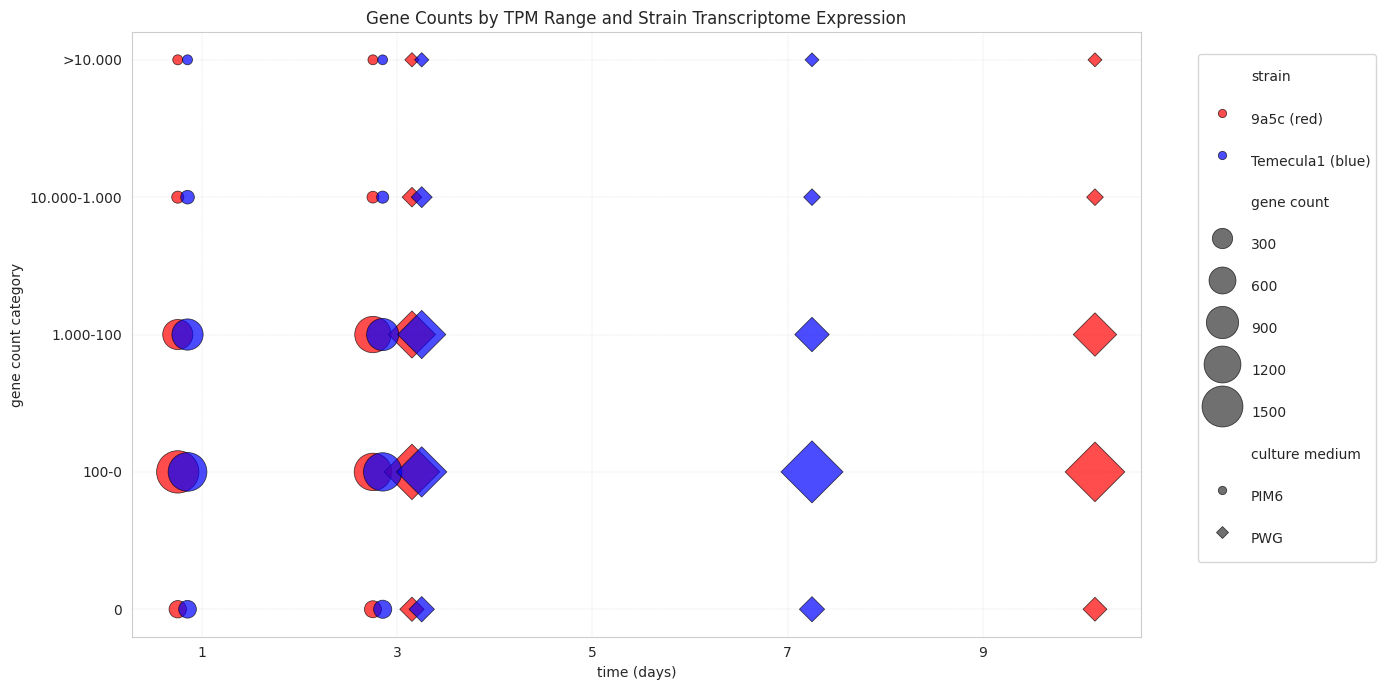

In [15]:
# Assuming tpm_summary is your DataFrame
# Add jitter function
def jitter_times(row):
    jitter_map_medium = {'PIM6': -0.2, 'PWG': 0.2}  # shift by medium
    jitter_map_strain = {'9a5c': -0.05, 'Temecula1': 0.05}  # further shift by strain
    jitter = jitter_map_medium.get(row['culture medium'], 0) + jitter_map_strain.get(row['strain'], 0)
    return row['time(days)'] + jitter

# Add jittered_time column
tpm_summary['jittered_time'] = tpm_summary.apply(jitter_times, axis=1)

# Reshape the data to long format
df_melted = tpm_summary.melt(
    id_vars=['strain', 'culture medium', 'time(days)', 'jittered_time'],
    value_vars=['>10.000', '10.000-1.000', '1.000-100', '100-0', '0'],
    var_name='gene count category',
    value_name='gene count'
)

# Create a custom palette mapping strains to specific colors
custom_palette = {'9a5c': 'red', 'Temecula1': 'blue'}

# Plot with custom colors
plt.figure(figsize=(14, 7))
sns.set_style("whitegrid")
ax = sns.scatterplot(
    data=df_melted,
    x="jittered_time",
    y="gene count category",
    size="gene count",
    hue="strain",
    style="culture medium",
    markers={'PIM6': 'o', 'PWG': 'D'},
    palette=custom_palette,  # Use our custom color mapping
    sizes=(50, 1000),
    edgecolor="black",
    alpha=0.7
)

# Customize legend to show the correct colors
handles, labels = ax.get_legend_handles_labels()

# Update legend labels for strains to match our custom colors
for i, label in enumerate(labels):
    if label in ['9a5c', 'Temecula1']:
        # Find the corresponding artist handle and update its color
        # Note: This would require more complex legend manipulation
        pass

# Update legend labels for clarity
new_labels = []
for label in labels:
    if label == '9a5c':
        new_labels.append('9a5c (red)')
    elif label == 'Temecula1':
        new_labels.append('Temecula1 (blue)')
    else:
        new_labels.append(label)

ax.legend(handles=handles, labels=new_labels, bbox_to_anchor=(1.05, 0.975),
          loc='upper left', borderaxespad=0.5, handleheight=3.5, handlelength=2.6, frameon=True)

# Adjust plot aesthetics
ax.grid(True, which='major', linestyle='--', linewidth=0.25, color='lightgrey')
min_time = int(tpm_summary['time(days)'].min())
max_time = int(tpm_summary['time(days)'].max())
odd_ticks = [t for t in range(min_time, max_time + 1) if t % 2 == 1]
ax.set_xticks(odd_ticks)
ax.set_xticklabels(odd_ticks)
ax.set_xlabel("time (days)")
plt.title("Gene Counts by TPM Range and Strain Transcriptome Expression")

plt.tight_layout()
plt.savefig('Gene_Counts_TPM.tiff', format='tiff', dpi=600)
plt.show()

In [ ]:
# GO annotations

In [48]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/figures_GO

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/figures_GO


In [63]:
pwd

'/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/figures_GO'

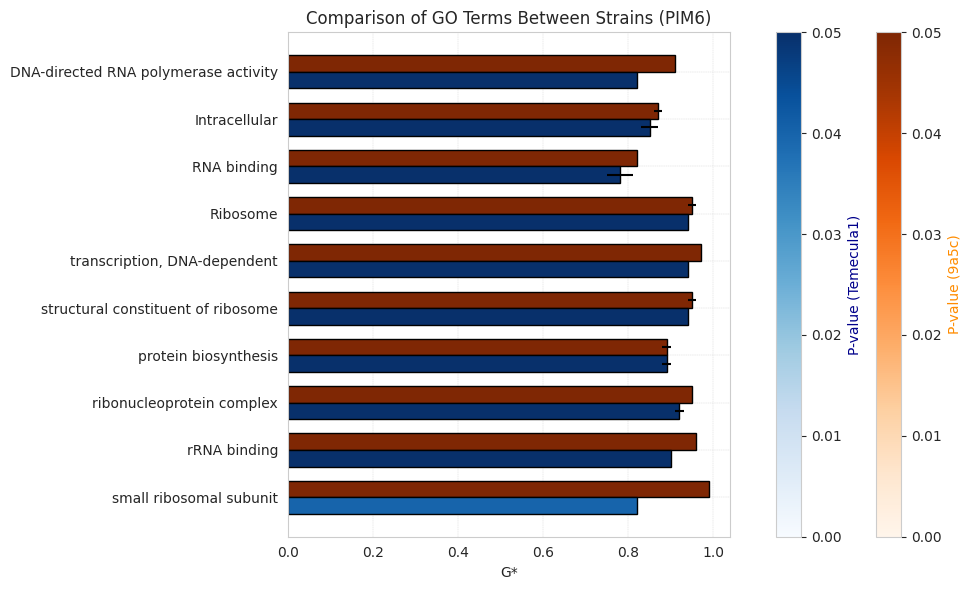

In [64]:
# Filter common GO terms with P <= 0.05 in both datasets
data_9a5c_up_early_exponential_versus_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0006457', 'GO:0051082', 'GO:0003723', 'GO:0006412', 'GO:0003746',
        'GO:0006414', 'GO:0003735', 'GO:0005622', 'GO:0005840', 'GO:0030529',
        'GO:0000049', 'GO:0015935', 'GO:0019843', 'GO:0003899', 'GO:0006350',
        'GO:0006351', 'GO:0016779', 'GO:0006986', 'GO:0045449', 'GO:0006886',
        'GO:0009306', 'GO:0015450', 'GO:0015934', 'GO:0042254'
    ],
    'Description': [
        'protein folding', 'unfolded protein binding', 'RNA binding',
        'protein biosynthesis', 'translation elongation factor activity',
        'translational elongation', 'structural constituent of ribosome',
        'Intracellular', 'Ribosome', 'ribonucleoprotein complex',
        'tRNA binding', 'small ribosomal subunit', 'rRNA binding',
        'DNA-directed RNA polymerase activity', 'Transcription',
        'transcription, DNA-dependent', 'nucleotidyltransferase activity',
        'response to unfolded protein', 'regulation of transcription',
        'intracellular protein transport', 'protein secretion',
        'protein translocase activity', 'large ribosomal subunit',
        'ribosome biogenesis and assembly'
    ],
    'G*': [
        0.61, 0.74, 0.82, 0.89, 0.81, 0.86, 0.95, 0.87, 0.95, 0.95,
        0.88, 0.99, 0.96, 0.91, 0.83, 0.97, 0.68, 0.82, 0.74, 0.90,
        0.64, 0.90, 0.93, 1.00
    ],
    'P': [
        0.01, 0.01, 0.0, 0.0, 0.03, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.02, 0.04, 0.0,
        0.04, 0.0, 0.0, 0.0
    ],
    'CI_lower': [
        0.61, 0.74, 0.82, 0.88, 0.81, 0.86, 0.95, 0.86, 0.95, 0.95,
        0.88, 0.99, 0.96, 0.91, 0.83, 0.97, 0.68, 0.82, 0.70, 0.90,
        0.64, 0.90, 0.93, 1.00
    ],
    'CI_upper': [
        0.61, 0.74, 0.82, 0.90, 0.81, 0.86, 0.96, 0.88, 0.96, 0.95,
        0.88, 0.99, 0.96, 0.91, 0.83, 0.97, 0.68, 0.82, 0.80, 0.90,
        0.64, 0.90, 0.93, 1.00
    ]
})

data_Temecula1_up_early_exponential_versus_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0003723', 'GO:0006412', 'GO:0003735', 'GO:0005622', 'GO:0005840',
        'GO:0030529', 'GO:0015935', 'GO:0019843', 'GO:0003899', 'GO:0006350',
        'GO:0006351', 'GO:0004222', 'GO:0042254', 'GO:0008237', 'GO:0006364'
    ],
    'Description': [
        'RNA binding', 'protein biosynthesis', 'structural constituent of ribosome',
        'Intracellular', 'Ribosome', 'ribonucleoprotein complex',
        'small ribosomal subunit', 'rRNA binding',
        'DNA-directed RNA polymerase activity', 'Transcription',
        'transcription, DNA-dependent', 'metalloendopeptidase activity',
        'ribosome biogenesis and assembly', 'metallopeptidase activity',
        'rRNA processing'
    ],
    'G*': [
        0.78, 0.89, 0.94, 0.85, 0.94, 0.92, 0.82, 0.90, 0.82, 0.73,
        0.94, 0.70, 1.00, 0.80, 0.72
    ],
    'P': [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.0, 0.04,
        0.0, 0.04, 0.01, 0.03, 0.03
    ],
    'CI_lower': [
        0.75, 0.87, 0.93, 0.83, 0.92, 0.92, 0.82, 0.90, 0.82, 0.67,
        0.94, 0.70, 1.00, 0.80, 0.72
    ],
    'CI_upper': [
        0.81, 0.90, 0.94, 0.87, 0.94, 0.93, 0.82, 0.90, 0.82, 0.83,
        0.94, 0.70, 1.00, 0.80, 0.72
    ]
})




# Filter only common GO annotations with p <= 0.05
df_9a5c = data_9a5c_up_early_exponential_versus_late_exponential_PIM6
p_filter_9a5c = df_9a5c[df_9a5c['P'] <= 0.05]

df_temecula = data_Temecula1_up_early_exponential_versus_late_exponential_PIM6
p_filter_temecula = df_temecula[df_temecula['P'] <= 0.05]

# Merge all GO terms that are significant in at least one strain
all_go = pd.merge(
    p_filter_9a5c,
    p_filter_temecula,
    on='GO annotation',
    how='outer',
    suffixes=('_9a5c', '_temecula')
)

# Fill missing values with zeros or appropriate defaults
all_go['G*_9a5c'] = all_go['G*_9a5c'].fillna(0)
all_go['G*_temecula'] = all_go['G*_temecula'].fillna(0)
all_go['P_9a5c'] = all_go['P_9a5c'].fillna(0.05)
all_go['P_temecula'] = all_go['P_temecula'].fillna(0.05)
all_go['CI_upper_9a5c'] = all_go['CI_upper_9a5c'].fillna(all_go['G*_9a5c'])
all_go['CI_upper_temecula'] = all_go['CI_upper_temecula'].fillna(all_go['G*_temecula'])

# Merge descriptions safely
all_go['Description'] = all_go['Description_9a5c'].combine_first(all_go['Description_temecula'])

# Sort by description
merged = all_go.sort_values(by='Description')
# Ordenar pelos termos com menor média de P-valor (mais significativos) e limitar a 10
merged['mean_P'] = (merged['P_9a5c'] + merged['P_temecula']) / 2
merged = merged.sort_values(by='mean_P').head(10)

# Set up the figure
fig, ax = plt.subplots(figsize=(10, len(merged) * 0.6))
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
ax.grid(True, axis='x', color='lightgrey', linestyle='--', linewidth=0.3)
ax.grid(True, axis='y', color='lightgrey', linestyle='--', linewidth=0.3)

bar_height = 0.35
indices = np.arange(len(merged))

norm_9a5c = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_9a5c = plt.cm.Oranges_r(norm_9a5c(merged['P_9a5c']))

norm_temecula = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_temecula = plt.cm.Blues_r(norm_temecula(merged['P_temecula']))

ax.barh(
    indices - bar_height/2,
    merged['G*_9a5c'],
    xerr=merged['CI_upper_9a5c'] - merged['G*_9a5c'],
    color=colors_9a5c,
    height=bar_height,
    edgecolor='black'
)

ax.barh(
    indices + bar_height/2,
    merged['G*_temecula'],
    xerr=merged['CI_upper_temecula'] - merged['G*_temecula'],
    color=colors_temecula,
    height=bar_height,
    edgecolor='black'
)

ax.set_yticks(indices)
ax.set_yticklabels(merged['Description'])
ax.invert_yaxis()
ax.set_xlabel('G*')
ax.set_title('Comparison of GO Terms Between Strains (PIM6)')

sm_9a5c = ScalarMappable(cmap='Oranges', norm=norm_9a5c)
sm_9a5c.set_array([])
cbar1 = plt.colorbar(sm_9a5c, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('P-value (9a5c)', color='darkorange')

sm_temecula = ScalarMappable(cmap='Blues', norm=norm_temecula)
sm_temecula.set_array([])
cbar2 = plt.colorbar(sm_temecula, ax=ax, orientation='vertical', pad=0.08)
cbar2.set_label('P-value (Temecula1)', color='darkblue')

plt.tight_layout()
plt.savefig("Beginning vs. End (PIM6) in both strains.tiff", dpi=600, format='tiff', bbox_inches='tight')
plt.show()

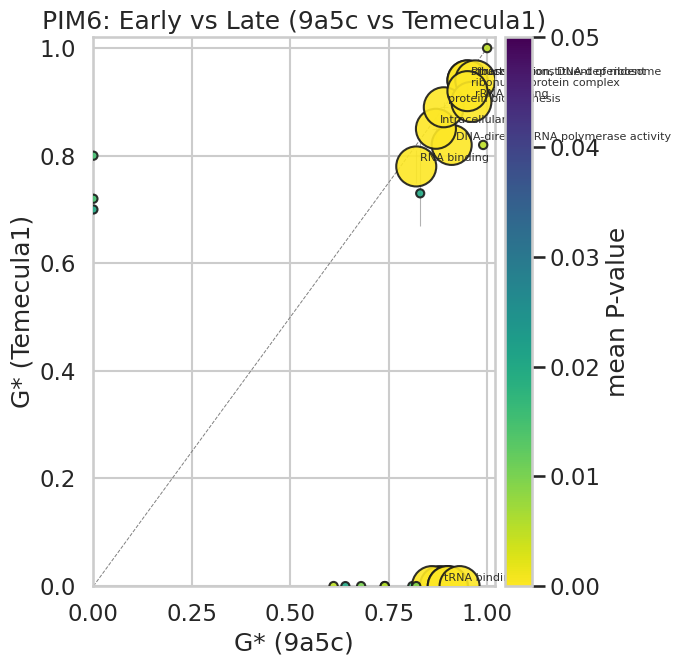

In [2]:
# Paired bubble scatter (single-panel) using your provided 9a5c and Temecula1 data
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable

sns.set(style="whitegrid", context="talk")

# -------------------------
# Your provided dataframes
# -------------------------
data_9a5c_up_early_exponential_versus_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0006457', 'GO:0051082', 'GO:0003723', 'GO:0006412', 'GO:0003746',
        'GO:0006414', 'GO:0003735', 'GO:0005622', 'GO:0005840', 'GO:0030529',
        'GO:0000049', 'GO:0015935', 'GO:0019843', 'GO:0003899', 'GO:0006350',
        'GO:0006351', 'GO:0016779', 'GO:0006986', 'GO:0045449', 'GO:0006886',
        'GO:0009306', 'GO:0015450', 'GO:0015934', 'GO:0042254'
    ],
    'Description': [
        'protein folding', 'unfolded protein binding', 'RNA binding',
        'protein biosynthesis', 'translation elongation factor activity',
        'translational elongation', 'structural constituent of ribosome',
        'Intracellular', 'Ribosome', 'ribonucleoprotein complex',
        'tRNA binding', 'small ribosomal subunit', 'rRNA binding',
        'DNA-directed RNA polymerase activity', 'Transcription',
        'transcription, DNA-dependent', 'nucleotidyltransferase activity',
        'response to unfolded protein', 'regulation of transcription',
        'intracellular protein transport', 'protein secretion',
        'protein translocase activity', 'large ribosomal subunit',
        'ribosome biogenesis and assembly'
    ],
    'G*': [
        0.61, 0.74, 0.82, 0.89, 0.81, 0.86, 0.95, 0.87, 0.95, 0.95,
        0.88, 0.99, 0.96, 0.91, 0.83, 0.97, 0.68, 0.82, 0.74, 0.90,
        0.64, 0.90, 0.93, 1.00
    ],
    'P': [
        0.01, 0.01, 0.0, 0.0, 0.03, 0.0, 0.0, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.02, 0.02, 0.04, 0.0,
        0.04, 0.0, 0.0, 0.0
    ],
    'CI_lower': [
        0.61, 0.74, 0.82, 0.88, 0.81, 0.86, 0.95, 0.86, 0.95, 0.95,
        0.88, 0.99, 0.96, 0.91, 0.83, 0.97, 0.68, 0.82, 0.70, 0.90,
        0.64, 0.90, 0.93, 1.00
    ],
    'CI_upper': [
        0.61, 0.74, 0.82, 0.90, 0.81, 0.86, 0.96, 0.88, 0.96, 0.95,
        0.88, 0.99, 0.96, 0.91, 0.83, 0.97, 0.68, 0.82, 0.80, 0.90,
        0.64, 0.90, 0.93, 1.00
    ]
})

data_Temecula1_up_early_exponential_versus_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0003723', 'GO:0006412', 'GO:0003735', 'GO:0005622', 'GO:0005840',
        'GO:0030529', 'GO:0015935', 'GO:0019843', 'GO:0003899', 'GO:0006350',
        'GO:0006351', 'GO:0004222', 'GO:0042254', 'GO:0008237', 'GO:0006364'
    ],
    'Description': [
        'RNA binding', 'protein biosynthesis', 'structural constituent of ribosome',
        'Intracellular', 'Ribosome', 'ribonucleoprotein complex',
        'small ribosomal subunit', 'rRNA binding',
        'DNA-directed RNA polymerase activity', 'Transcription',
        'transcription, DNA-dependent', 'metalloendopeptidase activity',
        'ribosome biogenesis and assembly', 'metallopeptidase activity',
        'rRNA processing'
    ],
    'G*': [
        0.78, 0.89, 0.94, 0.85, 0.94, 0.92, 0.82, 0.90, 0.82, 0.73,
        0.94, 0.70, 1.00, 0.80, 0.72
    ],
    'P': [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01, 0.0, 0.0, 0.04,
        0.0, 0.04, 0.01, 0.03, 0.03
    ],
    'CI_lower': [
        0.75, 0.87, 0.93, 0.83, 0.92, 0.92, 0.82, 0.90, 0.82, 0.67,
        0.94, 0.70, 1.00, 0.80, 0.72
    ],
    'CI_upper': [
        0.81, 0.90, 0.94, 0.87, 0.94, 0.93, 0.82, 0.90, 0.82, 0.83,
        0.94, 0.70, 1.00, 0.80, 0.72
    ]
})

# -------------------------
# Merge the two frames
# -------------------------
# Prepare and merge (same as before)
df1 = data_9a5c_up_early_exponential_versus_late_exponential_PIM6.rename(
    columns={'G*': 'G*_9a5c', 'P': 'P_9a5c', 'CI_lower': 'CI_lower_9a5c', 'CI_upper': 'CI_upper_9a5c', 'Description':'Description_9a5c'}
)
df2 = data_Temecula1_up_early_exponential_versus_late_exponential_PIM6.rename(
    columns={'G*': 'G*_temecula', 'P': 'P_temecula', 'CI_lower': 'CI_lower_temecula', 'CI_upper': 'CI_upper_temecula', 'Description':'Description_temecula'}
)
merged = pd.merge(df1, df2, on='GO annotation', how='outer')
merged['Description'] = merged['Description_9a5c'].combine_first(merged['Description_temecula'])

# Fill missing numeric values
for col in ['G*_9a5c','G*_temecula','P_9a5c','P_temecula']:
    merged[col] = merged.get(col, 0.0).fillna(0.0)
# CI fallback -> set equal to center G* if missing
merged['CI_lower_9a5c'] = merged.get('CI_lower_9a5c', merged['G*_9a5c']).fillna(merged['G*_9a5c'])
merged['CI_upper_9a5c'] = merged.get('CI_upper_9a5c', merged['G*_9a5c']).fillna(merged['G*_9a5c'])
merged['CI_lower_temecula'] = merged.get('CI_lower_temecula', merged['G*_temecula']).fillna(merged['G*_temecula'])
merged['CI_upper_temecula'] = merged.get('CI_upper_temecula', merged['G*_temecula']).fillna(merged['G*_temecula'])

# Plotting function (fixed errorbar handling)
def plot_paired_bubble(ax, dfm, title="", label_top_n=8, size_scale=600):
    df = dfm.copy().reset_index(drop=True)

    eps = 1e-300
    df['mean_P'] = (df['P_9a5c'] + df['P_temecula']) / 2.0
    # size metric: more significant => bigger
    df['sig'] = -np.log10(df['mean_P'].clip(lower=eps))
    sizes = (df['sig'] / (df['sig'].max() + 1e-9)) * size_scale + 30

    norm = Normalize(vmin=0.0, vmax=0.05)
    cmap = plt.cm.viridis_r

    # compute asymmetric errors per row when plotting
    sc = ax.scatter(df['G*_9a5c'], df['G*_temecula'], s=sizes, c=df['mean_P'], cmap=cmap, norm=norm,
                    edgecolor='k', alpha=0.9, zorder=3)

    # add per-point asymmetric errorbars. For single point Matplotlib expects xerr shape (2, n) where n = number of points.
    # Here we plot one-by-one, so we pass xerr/yerr with shape (2,1) as a 2x1 array.
    for i, row in df.iterrows():
        xl = float(row['G*_9a5c'] - row['CI_lower_9a5c'])
        xh = float(row['CI_upper_9a5c'] - row['G*_9a5c'])
        yl = float(row['G*_temecula'] - row['CI_lower_temecula'])
        yh = float(row['CI_upper_temecula'] - row['G*_temecula'])

        # defensive: do not allow negative error widths
        xl = max(xl, 0.0)
        xh = max(xh, 0.0)
        yl = max(yl, 0.0)
        yh = max(yh, 0.0)

        xerr = np.array([[xl], [xh]])   # shape (2,1)
        yerr = np.array([[yl], [yh]])   # shape (2,1)

        ax.errorbar(row['G*_9a5c'], row['G*_temecula'],
                    xerr=xerr, yerr=yerr,
                    fmt='none', ecolor='gray', alpha=0.6, linewidth=0.8, zorder=2)

    # identity line
    maxval = max(df[['G*_9a5c','G*_temecula']].max().max(), 1.0)
    ax.plot([0, maxval], [0, maxval], linestyle='--', color='gray', linewidth=0.7, zorder=1)

    # annotate top terms by mean_P (most significant)
    top = df.sort_values('mean_P').head(label_top_n)
    for _, r in top.iterrows():
        ax.text(r['G*_9a5c'] + 0.01, r['G*_temecula'] + 0.01, r['Description'],
                fontsize=8, alpha=0.95)

    ax.set_xlabel("G* (9a5c)")
    ax.set_ylabel("G* (Temecula1)")
    ax.set_title(title)
    ax.set_xlim(0, maxval*1.02)
    ax.set_ylim(0, maxval*1.02)

    sm = ScalarMappable(cmap=cmap, norm=norm)
    sm.set_array([])
    cbar = plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.02)
    cbar.set_label('mean P-value')

    return sc

# Draw
fig, ax = plt.subplots(figsize=(7,7))
plot_paired_bubble(ax, merged, title="PIM6: Early vs Late (9a5c vs Temecula1)", label_top_n=10, size_scale=800)
plt.tight_layout()
plt.show()

# If you later want a 6-panel figure, put the merged DataFrames for each comparison into a dict
# and loop over them, creating subplots like in the earlier example.


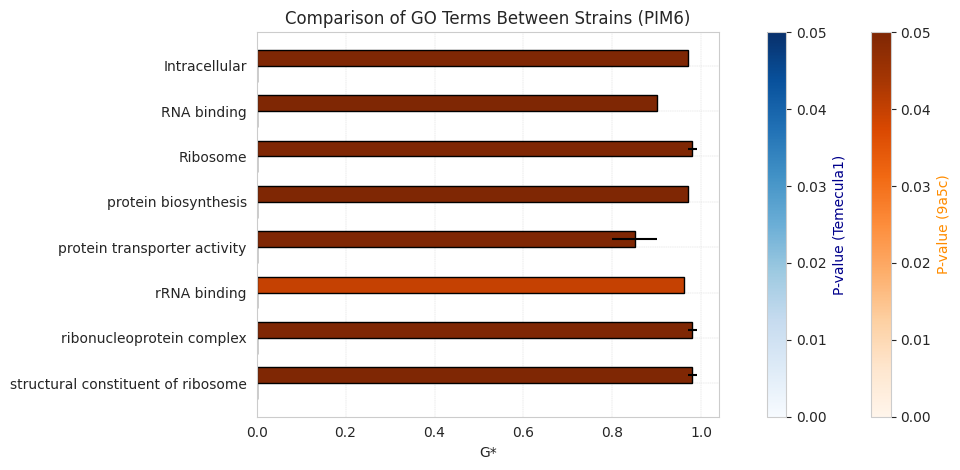

In [66]:
# Filter common GO terms with P <= 0.05 in both datasets
data_9a5c_up_late_exponential_PWG_vs_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0003723', 'GO:0006412', 'GO:0003735', 'GO:0005622',
        'GO:0005840', 'GO:0030529', 'GO:0019843', 'GO:0008565'
    ],
    'Description': [
        'RNA binding', 'protein biosynthesis', 'structural constituent of ribosome',
        'Intracellular', 'Ribosome', 'ribonucleoprotein complex',
        'rRNA binding', 'protein transporter activity'
    ],
    'G*': [
        0.90, 0.97, 0.98, 0.97, 0.98, 0.98, 0.96, 0.85
    ],
    'P': [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.01, 0.0
    ],
    'CI_lower': [
        0.90, 0.96, 0.98, 0.96, 0.97, 0.98, 0.96, 0.83
    ],
    'CI_upper': [
        0.90, 0.97, 0.99, 0.97, 0.99, 0.99, 0.96, 0.90
    ]
})

data_Temecula1_up_late_exponential_PWG_vs_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0003723', 'GO:0006412', 'GO:0003735', 'GO:0005622',
        'GO:0005840', 'GO:0030529', 'GO:0019843', 'GO:0008565'
    ],
    'Description': [
        'RNA binding', 'protein biosynthesis', 'structural constituent of ribosome',
        'Intracellular', 'Ribosome', 'ribonucleoprotein complex',
        'rRNA binding', 'protein transporter activity'
    ],
    'G*': [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ],
    'P': [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ],
    'CI_lower': [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ],
    'CI_upper': [
        0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0
    ]
})


# Filter only common GO annotations with p <= 0.05
df_9a5c = data_9a5c_up_late_exponential_PWG_vs_late_exponential_PIM6
p_filter_9a5c = df_9a5c[df_9a5c['P'] <= 0.05]

df_temecula = data_Temecula1_up_late_exponential_PWG_vs_late_exponential_PIM6
p_filter_temecula = df_temecula[df_temecula['P'] <= 0.05]

common_go = set(p_filter_9a5c['GO annotation']).intersection(set(p_filter_temecula['GO annotation']))

df_9a5c_common = p_filter_9a5c[p_filter_9a5c['GO annotation'].isin(common_go)].copy()
df_temecula_common = p_filter_temecula[p_filter_temecula['GO annotation'].isin(common_go)].copy()

# Sort by description alphabetically for consistency
merged = pd.merge(
    df_9a5c_common,
    df_temecula_common,
    on='GO annotation',
    suffixes=('_9a5c', '_temecula')
).sort_values(by='Description_9a5c', ascending=True)

# Set up the figure
fig, ax = plt.subplots(figsize=(10, len(merged) * 0.6))
# fig, ax = plt.subplots(figsize=(10, len(merged) * 0.5))

# Defina fundo transparente ou corlesso
fig.patch.set_alpha(0.0)      # figure background
ax.set_facecolor('none')      # background axis tansparent

# Linhas de grade suaves e cinza-claro
ax.grid(True, axis='x', color='lightgrey', linestyle='--', linewidth=0.3)
ax.grid(True, axis='y', color='lightgrey', linestyle='--', linewidth=0.3)

bar_height = 0.35
indices = np.arange(len(merged))


# Color normalization and maps
# norm_9a5c = Normalize(vmin=merged['P_9a5c'].min(), vmax=merged['P_9a5c'].max())
norm_9a5c = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_9a5c = plt.cm.Oranges_r(norm_9a5c(merged['P_9a5c']))

# norm_temecula = Normalize(vmin=merged['P_temecula'].min(), vmax=merged['P_temecula'].max())
norm_temecula = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_temecula = plt.cm.Blues_r(norm_temecula(merged['P_temecula']))

# Plot bars
ax.barh(
    indices - bar_height/2,
    merged['G*_9a5c'],
    xerr=merged['CI_upper_9a5c'] - merged['G*_9a5c'],
    color=colors_9a5c,
    height=bar_height,
    edgecolor='black'
)

ax.barh(
    indices + bar_height/2,
    merged['G*_temecula'],
    xerr=merged['CI_upper_temecula'] - merged['G*_temecula'],
    color=colors_temecula,
    height=bar_height,
    edgecolor='black'
)

# Labels and ticks
ax.set_yticks(indices)
ax.set_yticklabels(merged['Description_9a5c'])
ax.invert_yaxis()
ax.set_xlabel('G*')
ax.set_title('Comparison of GO Terms Between Strains (PIM6)')

# Add colorbars for p-values
sm_9a5c = ScalarMappable(cmap='Oranges', norm=norm_9a5c)
sm_9a5c.set_array([])
cbar1 = plt.colorbar(sm_9a5c, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('P-value (9a5c)', color='darkorange')

sm_temecula = ScalarMappable(cmap='Blues', norm=norm_temecula)
sm_temecula.set_array([])
cbar2 = plt.colorbar(sm_temecula, ax=ax, orientation='vertical', pad=0.08)
cbar2.set_label('P-value (Temecula1)', color='darkblue')

plt.tight_layout()
plt.savefig("Comparison of means (PWG vs PIM6) in 9a5c.tiff", dpi=600, format='tiff', bbox_inches='tight')
plt.show()

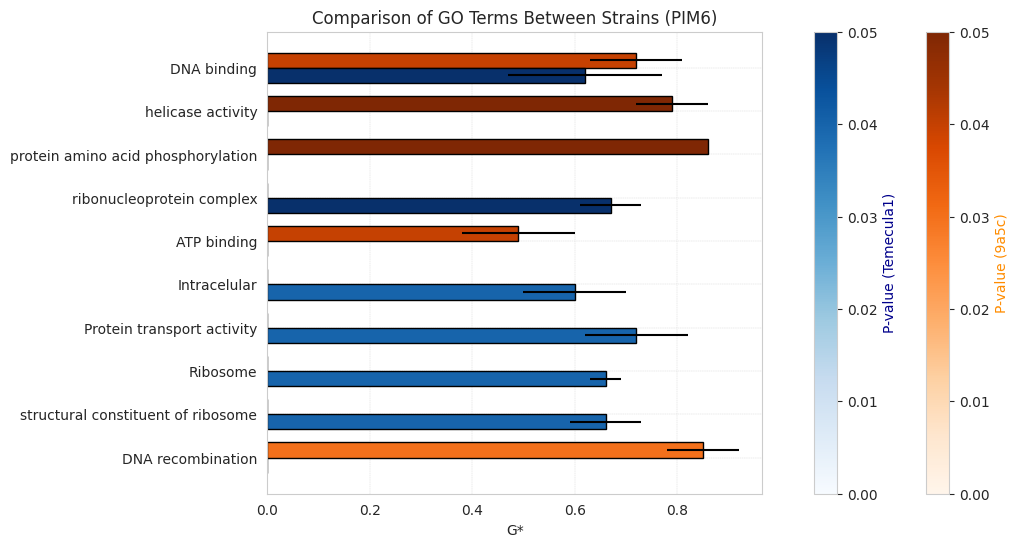

In [67]:
# Filter common GO terms with P <= 0.05 in both datasets
data_9a5c_vs_Temecula1_up_early_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0005524', 'GO:0003677', 'GO:0006310', 'GO:0003676',
        'GO:0004386', 'GO:0006468', 'GO:0016874'
    ],
    'Description': [
        'ATP binding', 'DNA binding', 'DNA recombination', 'nucleic acid binding',
        'helicase activity', 'protein amino acid phosphorylation', 'ligase activity'
    ],
    'G*': [
        0.49, 0.72, 0.85, 0.62, 0.79, 0.86, 0.48
    ],
    'P': [
        0.01, 0.01, 0.02, 0.04, 0.0, 0.0, 0.04
    ],
    'CI_lower': [
        0.41, 0.60, 0.78, 0.51, 0.74, 0.86, 0.40
    ],
    'CI_upper': [
        0.60, 0.81, 0.92, 0.77, 0.86, 0.86, 0.52
    ]
})

data_Temecula1_vs_9a5c_up_early_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0006412', 'GO:0003677', 'GO:0003735', 'GO:0005622',
        'GO:0005840', 'GO:0030529', 'GO:0008565'
    ],
    'Description': [
        'protein biosynthesis', 'DNA binding', 'structural constituent of ribosome',
        'Intracelular', 'Ribosome', 'ribonucleoprotein complex',
        'Protein transport activity'
    ],
    'G*': [
        0.45, 0.62, 0.66, 0.60, 0.66, 0.67, 0.72
    ],
    'P': [
        0.03, 0.0, 0.01, 0.01, 0.01, 0.0, 0.01
    ],
    'CI_lower': [
        0.39, 0.49, 0.60, 0.54, 0.60, 0.60, 0.66
    ],
    'CI_upper': [
        0.60, 0.77, 0.73, 0.70, 0.69, 0.73, 0.82
    ]
})


# Filter only common GO annotations with p <= 0.05
df_9a5c = data_9a5c_vs_Temecula1_up_early_exponential_PIM6
p_filter_9a5c = df_9a5c[df_9a5c['P'] <= 0.05]

df_temecula = data_Temecula1_vs_9a5c_up_early_exponential_PIM6
p_filter_temecula = df_temecula[df_temecula['P'] <= 0.05]

# Merge all GO terms that are significant in at least one strain
all_go = pd.merge(
    p_filter_9a5c,
    p_filter_temecula,
    on='GO annotation',
    how='outer',
    suffixes=('_9a5c', '_temecula')
)

# Fill missing values with zeros or appropriate defaults
all_go['G*_9a5c'] = all_go['G*_9a5c'].fillna(0)
all_go['G*_temecula'] = all_go['G*_temecula'].fillna(0)
all_go['P_9a5c'] = all_go['P_9a5c'].fillna(0.05)
all_go['P_temecula'] = all_go['P_temecula'].fillna(0.05)
all_go['CI_upper_9a5c'] = all_go['CI_upper_9a5c'].fillna(all_go['G*_9a5c'])
all_go['CI_upper_temecula'] = all_go['CI_upper_temecula'].fillna(all_go['G*_temecula'])

# Merge descriptions safely
all_go['Description'] = all_go['Description_9a5c'].combine_first(all_go['Description_temecula'])

# Sort by description
merged = all_go.sort_values(by='Description')
# Ordenar pelos termos com menor média de P-valor (mais significativos) e limitar a 10
merged['mean_P'] = (merged['P_9a5c'] + merged['P_temecula']) / 2
merged = merged.sort_values(by='mean_P').head(10)

# Set up the figure
fig, ax = plt.subplots(figsize=(10, len(merged) * 0.6))
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
ax.grid(True, axis='x', color='lightgrey', linestyle='--', linewidth=0.3)
ax.grid(True, axis='y', color='lightgrey', linestyle='--', linewidth=0.3)

bar_height = 0.35
indices = np.arange(len(merged))

norm_9a5c = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_9a5c = plt.cm.Oranges_r(norm_9a5c(merged['P_9a5c']))

norm_temecula = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_temecula = plt.cm.Blues_r(norm_temecula(merged['P_temecula']))

ax.barh(
    indices - bar_height/2,
    merged['G*_9a5c'],
    xerr=merged['CI_upper_9a5c'] - merged['G*_9a5c'],
    color=colors_9a5c,
    height=bar_height,
    edgecolor='black'
)

ax.barh(
    indices + bar_height/2,
    merged['G*_temecula'],
    xerr=merged['CI_upper_temecula'] - merged['G*_temecula'],
    color=colors_temecula,
    height=bar_height,
    edgecolor='black'
)

ax.set_yticks(indices)
ax.set_yticklabels(merged['Description'])
ax.invert_yaxis()
ax.set_xlabel('G*')
ax.set_title('Comparison of GO Terms Between Strains (PIM6)')

sm_9a5c = ScalarMappable(cmap='Oranges', norm=norm_9a5c)
sm_9a5c.set_array([])
cbar1 = plt.colorbar(sm_9a5c, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('P-value (9a5c)', color='darkorange')

sm_temecula = ScalarMappable(cmap='Blues', norm=norm_temecula)
sm_temecula.set_array([])
cbar2 = plt.colorbar(sm_temecula, ax=ax, orientation='vertical', pad=0.08)
cbar2.set_label('P-value (Temecula1)', color='darkblue')

plt.tight_layout
plt.savefig("9a5c vs Temecula1_early_PIM6.tiff", dpi=600, format='tiff', bbox_inches='tight')
plt.show()

In [18]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/figures_GO

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22/figures_GO


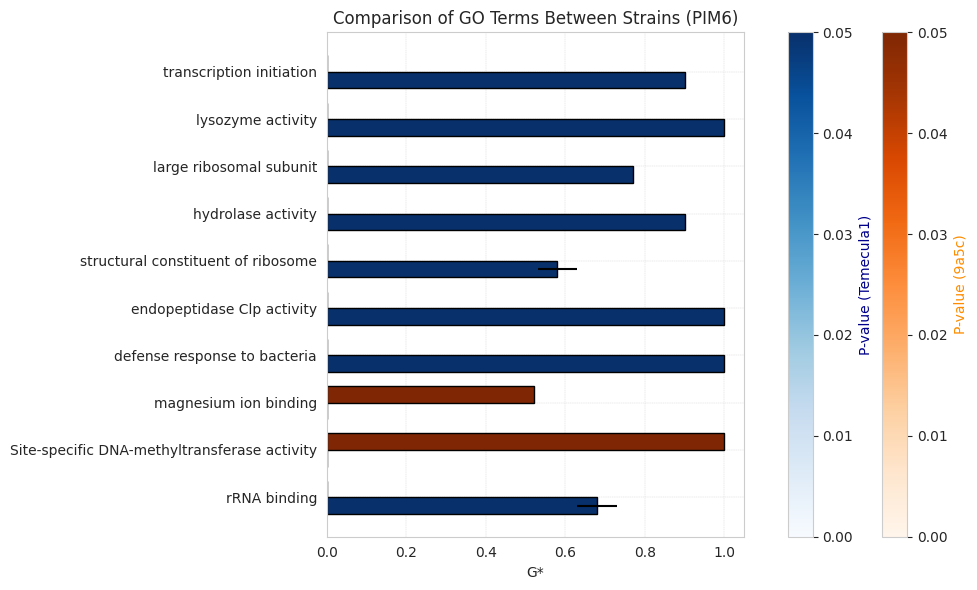

In [74]:
# Filter common GO terms with P <= 0.05 in both datasets
data_9a5c_vs_Temecula1_up_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0000287', 'GO:0006306', 'GO:0008170', 'GO:0009007',
        'GO:0006468', 'GO:0015074'
    ],
    'Description': [
        'magnesium ion binding', 'DNA-methylation', 'N-methyltransferase activity',
        'Site-specific DNA-methyltransferase activity',
        'Protein amino acid phosphorylation', 'DNA integration'
    ],
    'G*': [
        0.52, 0.95, 0.95, 1.00, 0.53, 0.91
    ],
    'P': [
        0.0, 0.02, 0.04, 0.0, 0.04, 0.03
    ],
    'CI_lower': [
        0.52, 0.76, 0.78, 1.00, 0.53, 0.77
    ],
    'CI_upper': [
        0.52, 0.99, 0.99, 1.00, 0.53, 0.97
    ]
})

data_Temecula1_vs_9a5c_up_late_exponential_PIM6 = pd.DataFrame({
    'GO annotation': [
        'GO:0003677', 'GO:0003735', 'GO:0005622', 'GO:0005840',
        'GO:0030529', 'GO:0015935', 'GO:0019843', 'GO:0003899',
        'GO:0006350', 'GO:0006355', 'GO:0003796', 'GO:0009253',
        'GO:0016998', 'GO:0019835', 'GO:0042742', 'GO:0006986',
        'GO:0015986', 'GO:0016469', 'GO:0046933', 'GO:0046961',
        'GO:0006352', 'GO:0016987', 'GO:0015031', 'GO:0015934',
        'GO:0008462', 'GO:0015992', 'GO:0016820', 'GO:0015078'
    ],
    'Description': [
        'DNA binding', 'structural constituent of ribosome', 'Intracellular',
        'Ribosome', 'ribonucleoprotein complex', 'small ribosomal subunit',
        'rRNA binding', 'DNA-directed RNA polymerase activity', 'Transcription',
        'regulation of transcription, DNA-dependent', 'lysozyme activity',
        'peptidoglycan catabolism', 'cell wall catabolism', 'Cytolysis',
        'defense response to bacteria', 'response to unfolded protein',
        'ATP synthesis coupled proton transport',
        'proton-transporting two-sector ATPase complex',
        'hydrogen-transporting ATP synthase activity, rotational mechanism',
        'hydrogen-transporting ATPase activity, rotational mechanism',
        'transcription initiation', 'sigma factor activity', 'protein transport',
        'large ribosomal subunit', 'endopeptidase Clp activity',
        'proton transport',
        'hydrolase activity',
        'hydrogen ion transporter activity'
    ],
    'G*': [
        0.41, 0.58, 0.47, 0.58, 0.60, 0.73, 0.68, 0.84, 0.59,
        0.50, 1.00, 0.90, 0.90, 0.97, 1.00, 0.69, 0.73, 0.69,
        0.73, 0.73, 0.90, 0.90, 0.61, 0.77, 1.00, 0.73, 0.90,
        0.77
    ],
    'P': [
        0.04, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.04,
        0.0, 0.0, 0.04, 0.02, 0.0, 0.0, 0.0, 0.02, 0.02,
        0.02, 0.02, 0.0, 0.02, 0.0, 0.0, 0.0, 0.02, 0.0,
        0.01
    ],
    'CI_lower': [
        0.29, 0.53, 0.39, 0.53, 0.56, 0.73, 0.64, 0.84, 0.51,
        0.40, 0.92, 0.76, 0.76, 0.94, 0.98, 0.69, 0.73, 0.69,
        0.73, 0.73, 0.90, 0.90, 0.61, 0.77, 0.95, 0.73, 0.90,
        0.77
    ],
    'CI_upper': [
        0.52, 0.63, 0.55, 0.64, 0.67, 0.73, 0.73, 0.84, 0.72,
        0.59, 1.00, 0.96, 0.96, 0.98, 1.00, 0.69, 0.73, 0.69,
        0.73, 0.73, 0.90, 0.90, 0.61, 0.77, 1.00, 0.73, 0.90,
        0.77
    ]
})


# Filter only common GO annotations with p <= 0.05
df_9a5c = data_9a5c_vs_Temecula1_up_late_exponential_PIM6
p_filter_9a5c = df_9a5c[df_9a5c['P'] <= 0.05]

df_temecula = data_Temecula1_vs_9a5c_up_late_exponential_PIM6
p_filter_temecula = df_temecula[df_temecula['P'] <= 0.05]

# Merge all GO terms that are significant in at least one strain
all_go = pd.merge(
    p_filter_9a5c,
    p_filter_temecula,
    on='GO annotation',
    how='outer',
    suffixes=('_9a5c', '_temecula')
)

# Fill missing values with zeros or appropriate defaults
all_go['G*_9a5c'] = all_go['G*_9a5c'].fillna(0)
all_go['G*_temecula'] = all_go['G*_temecula'].fillna(0)
all_go['P_9a5c'] = all_go['P_9a5c'].fillna(0.05)
all_go['P_temecula'] = all_go['P_temecula'].fillna(0.05)
all_go['CI_upper_9a5c'] = all_go['CI_upper_9a5c'].fillna(all_go['G*_9a5c'])
all_go['CI_upper_temecula'] = all_go['CI_upper_temecula'].fillna(all_go['G*_temecula'])

# Merge descriptions safely
all_go['Description'] = all_go['Description_9a5c'].combine_first(all_go['Description_temecula'])

# Sort by description
merged = all_go.sort_values(by='Description')
# Ordenar pelos termos com menor média de P-valor (mais significativos) e limitar a 10
merged['mean_P'] = (merged['P_9a5c'] + merged['P_temecula']) / 2
merged = merged.sort_values(by='mean_P').head(10)

# Set up the figure
fig, ax = plt.subplots(figsize=(10, len(merged) * 0.6))
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
ax.grid(True, axis='x', color='lightgrey', linestyle='--', linewidth=0.3)
ax.grid(True, axis='y', color='lightgrey', linestyle='--', linewidth=0.3)

bar_height = 0.35
indices = np.arange(len(merged))

norm_9a5c = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_9a5c = plt.cm.Oranges_r(norm_9a5c(merged['P_9a5c']))

norm_temecula = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_temecula = plt.cm.Blues_r(norm_temecula(merged['P_temecula']))

ax.barh(
    indices - bar_height/2,
    merged['G*_9a5c'],
    xerr=merged['CI_upper_9a5c'] - merged['G*_9a5c'],
    color=colors_9a5c,
    height=bar_height,
    edgecolor='black'
)

ax.barh(
    indices + bar_height/2,
    merged['G*_temecula'],
    xerr=merged['CI_upper_temecula'] - merged['G*_temecula'],
    color=colors_temecula,
    height=bar_height,
    edgecolor='black'
)

# depois de ax.barh(...)
# ax.set_axisbelow(True)
# ax.grid(
#     which='major',
#     axis='x',
#     color='lightgrey',
#     linestyle='--',
#     linewidth=0.01,
#     alpha=0.01,
#     zorder=0
# )

ax.set_yticks(indices)
ax.set_yticklabels(merged['Description'])
ax.invert_yaxis()
ax.set_xlabel('G*')
ax.set_title('Comparison of GO Terms Between Strains (PIM6)')

sm_9a5c = ScalarMappable(cmap='Oranges', norm=norm_9a5c)
sm_9a5c.set_array([])
cbar1 = plt.colorbar(sm_9a5c, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('P-value (9a5c)', color='darkorange')

sm_temecula = ScalarMappable(cmap='Blues', norm=norm_temecula)
sm_temecula.set_array([])
cbar2 = plt.colorbar(sm_temecula, ax=ax, orientation='vertical', pad=0.08)
cbar2.set_label('P-value (Temecula1)', color='darkblue')

plt.tight_layout()
plt.savefig("9a5c vs Temecula1_late_PIM6.tiff", dpi=600, format='tiff', bbox_inches='tight')
plt.show()

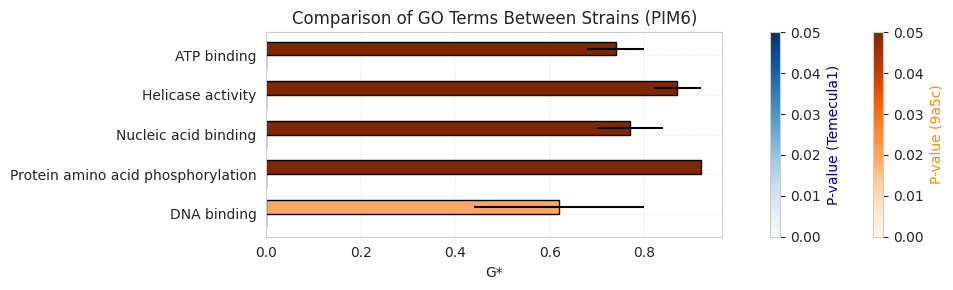

In [70]:
# Filter common GO terms with P <= 0.05 in both datasets
data_9a5c_vs_Temecula1_up_early_exponential_PWG = pd.DataFrame({
    'GO annotation': [
        'GO:0005524', 'GO:0003677', 'GO:0003676', 'GO:0004386',
        'GO:0006468'
    ],
    'Description': [
        'ATP binding', 'DNA binding', 'Nucleic acid binding',
        'Helicase activity', 'Protein amino acid phosphorylation'
    ],
    'G*': [
        0.74, 0.62, 0.77, 0.87, 0.92
    ],
    'P': [
        0.0, 0.03, 0.0, 0.0, 0.0
    ],
    'CI_lower': [
        0.67, 0.46, 0.69, 0.83, 0.92
    ],
    'CI_upper': [
        0.80, 0.80, 0.84, 0.92, 0.92
    ]
})

data_Temecula1_vs_9a5c_up_early_exponential_PWG = pd.DataFrame({
    'GO annotation': [
        'GO:0005524', 'GO:0003677', 'GO:0003676', 'GO:0004386',
        'GO:0006468'
    ],
    'Description': [
        'ATP binding', 'DNA binding', 'Nucleic acid binding',
        'Helicase activity', 'Protein amino acid phosphorylation'
    ],
    'G*': [
        0.0, 0.0, 0.0, 0.0, 0.0
    ],
    'P': [
        0.0, 0.0, 0.0, 0.0, 0.0
    ],
    'CI_lower': [
        0.0, 0.0, 0.0, 0.0, 0.0
    ],
    'CI_upper': [
        0.0, 0.0, 0.0, 0.0, 0.0
    ]
})


# Filter only common GO annotations with p <= 0.05
df_9a5c = data_9a5c_vs_Temecula1_up_early_exponential_PWG
p_filter_9a5c = df_9a5c[df_9a5c['P'] <= 0.05]

df_temecula = data_Temecula1_vs_9a5c_up_early_exponential_PWG
p_filter_temecula = df_temecula[df_temecula['P'] <= 0.05]

# Merge all GO terms that are significant in at least one strain
all_go = pd.merge(
    p_filter_9a5c,
    p_filter_temecula,
    on='GO annotation',
    how='outer',
    suffixes=('_9a5c', '_temecula')
)

# Fill missing values with zeros or appropriate defaults
all_go['G*_9a5c'] = all_go['G*_9a5c'].fillna(0)
all_go['G*_temecula'] = all_go['G*_temecula'].fillna(0)
all_go['P_9a5c'] = all_go['P_9a5c'].fillna(0.05)
all_go['P_temecula'] = all_go['P_temecula'].fillna(0.05)
all_go['CI_upper_9a5c'] = all_go['CI_upper_9a5c'].fillna(all_go['G*_9a5c'])
all_go['CI_upper_temecula'] = all_go['CI_upper_temecula'].fillna(all_go['G*_temecula'])

# Merge descriptions safely
all_go['Description'] = all_go['Description_9a5c'].combine_first(all_go['Description_temecula'])

# Sort by description
merged = all_go.sort_values(by='Description')
# Ordenar pelos termos com menor média de P-valor (mais significativos) e limitar a 10
merged['mean_P'] = (merged['P_9a5c'] + merged['P_temecula']) / 2
merged = merged.sort_values(by='mean_P').head(10)

# Set up the figure
fig, ax = plt.subplots(figsize=(10, len(merged) * 0.6))
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
ax.grid(True, axis='x', color='lightgrey', linestyle='--', linewidth=0.3)
ax.grid(True, axis='y', color='lightgrey', linestyle='--', linewidth=0.3)

bar_height = 0.35
indices = np.arange(len(merged))

norm_9a5c = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_9a5c = plt.cm.Oranges_r(norm_9a5c(merged['P_9a5c']))

norm_temecula = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_temecula = plt.cm.Blues_r(norm_temecula(merged['P_temecula']))

ax.barh(
    indices - bar_height/2,
    merged['G*_9a5c'],
    xerr=merged['CI_upper_9a5c'] - merged['G*_9a5c'],
    color=colors_9a5c,
    height=bar_height,
    edgecolor='black'
)

ax.barh(
    indices + bar_height/2,
    merged['G*_temecula'],
    xerr=merged['CI_upper_temecula'] - merged['G*_temecula'],
    color=colors_temecula,
    height=bar_height,
    edgecolor='black'
)

ax.set_yticks(indices)
ax.set_yticklabels(merged['Description'])
ax.invert_yaxis()
ax.set_xlabel('G*')
ax.set_title('Comparison of GO Terms Between Strains (PIM6)')

sm_9a5c = ScalarMappable(cmap='Oranges', norm=norm_9a5c)
sm_9a5c.set_array([])
cbar1 = plt.colorbar(sm_9a5c, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('P-value (9a5c)', color='darkorange')

sm_temecula = ScalarMappable(cmap='Blues', norm=norm_temecula)
sm_temecula.set_array([])
cbar2 = plt.colorbar(sm_temecula, ax=ax, orientation='vertical', pad=0.08)
cbar2.set_label('P-value (Temecula1)', color='darkblue')

plt.tight_layout()
plt.savefig("9a5c vs Temecula1_early_PWG.tiff", dpi=600, format='tiff', bbox_inches='tight')
plt.show()

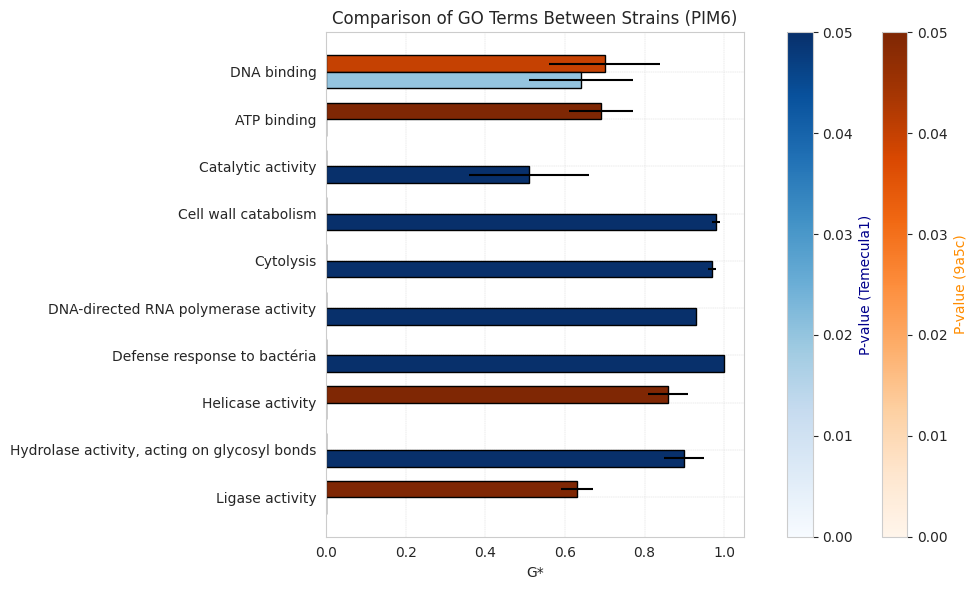

In [76]:
# Filter common GO terms with P <= 0.05 in both datasets
data_9a5c_vs_Temecula1_up_late_exponential_PWG = pd.DataFrame({
    'GO annotation': [
        'GO:0005524', 'GO:0003677', 'GO:0003676', 'GO:0004386',
        'GO:0016874'
    ],
    'Description': [
        'ATP binding', 'DNA binding', 'Nucleic acid binding',
        'Helicase activity', 'Ligase activity'
    ],
    'G*': [
        0.69, 0.70, 0.74, 0.86, 0.63
    ],
    'P': [
        0.0, 0.01, 0.0, 0.0, 0.0
    ],
    'CI_lower': [
        0.60, 0.61, 0.66, 0.82, 0.55
    ],
    'CI_upper': [
        0.77, 0.84, 0.85, 0.91, 0.67
    ]
})

data_Temecula1_vs_9a5c_up_late_exponential_PWG = pd.DataFrame({
    'GO annotation': [
        'GO:0003677', 'GO:0003824', 'GO:0005975', 'GO:0016798',
        'GO:0008152', 'GO:0003899', 'GO:0016779', 'GO:0003796',
        'GO:0009253', 'GO:0016998', 'GO:0019835', 'GO:0042742'
    ],
    'Description': [
        'DNA binding', 'Catalytic activity', 'Carbohydrate metabolismo',
        'Hydrolase activity, acting on glycosyl bonds', 'Metabolismo',
        'DNA-directed RNA polymerase activity', 'Nucleotidyltransferase activity',
        'Lysozyme activity', 'Peptidoglycan catabolism', 'Cell wall catabolism',
        'Cytolysis', 'Defense response to bactéria'
    ],
    'G*': [
        0.64, 0.51, 0.70, 0.90, 0.52, 0.93, 0.78, 1.00,
        0.98, 0.98, 0.97, 1.00
    ],
    'P': [
        0.03, 0.0, 0.03, 0.0, 0.03, 0.0, 0.0, 0.0,
        0.0, 0.0, 0.0, 0.0
    ],
    'CI_lower': [
        0.50, 0.44, 0.57, 0.83, 0.44, 0.93, 0.72, 0.98,
        0.94, 0.94, 0.94, 0.98
    ],
    'CI_upper': [
        0.77, 0.66, 0.84, 0.95, 0.64, 0.93, 0.85, 1.00,
        0.99, 0.99, 0.98, 1.00
    ]
})


# Filter only common GO annotations with p <= 0.05
df_9a5c = data_9a5c_vs_Temecula1_up_late_exponential_PWG
p_filter_9a5c = df_9a5c[df_9a5c['P'] <= 0.05]

df_temecula = data_Temecula1_vs_9a5c_up_late_exponential_PWG
p_filter_temecula = df_temecula[df_temecula['P'] <= 0.05]

# Merge all GO terms that are significant in at least one strain
all_go = pd.merge(
    p_filter_9a5c,
    p_filter_temecula,
    on='GO annotation',
    how='outer',
    suffixes=('_9a5c', '_temecula')
)

# Fill missing values with zeros or appropriate defaults
all_go['G*_9a5c'] = all_go['G*_9a5c'].fillna(0)
all_go['G*_temecula'] = all_go['G*_temecula'].fillna(0)
all_go['P_9a5c'] = all_go['P_9a5c'].fillna(0.05)
all_go['P_temecula'] = all_go['P_temecula'].fillna(0.05)
all_go['CI_upper_9a5c'] = all_go['CI_upper_9a5c'].fillna(all_go['G*_9a5c'])
all_go['CI_upper_temecula'] = all_go['CI_upper_temecula'].fillna(all_go['G*_temecula'])

# Merge descriptions safely
all_go['Description'] = all_go['Description_9a5c'].combine_first(all_go['Description_temecula'])

# Sort by description
merged = all_go.sort_values(by='Description')
# Ordenar pelos termos com menor média de P-valor (mais significativos) e limitar a 10
merged['mean_P'] = (merged['P_9a5c'] + merged['P_temecula']) / 2
merged = merged.sort_values(by='mean_P').head(10)

# Set up the figure
fig, ax = plt.subplots(figsize=(10, len(merged) * 0.6))
fig.patch.set_alpha(0.0)
ax.set_facecolor('none')
# ax.set_facecolor('white')
ax.grid(True, axis='x', color='lightgrey', linestyle='--', linewidth=0.3)
ax.grid(True, axis='y', color='lightgrey', linestyle='--', linewidth=0.3)

bar_height = 0.35
indices = np.arange(len(merged))

norm_9a5c = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_9a5c = plt.cm.Oranges_r(norm_9a5c(merged['P_9a5c']))

norm_temecula = mcolors.Normalize(vmin=0.0, vmax=0.05)
colors_temecula = plt.cm.Blues_r(norm_temecula(merged['P_temecula']))

ax.barh(
    indices - bar_height/2,
    merged['G*_9a5c'],
    xerr=merged['CI_upper_9a5c'] - merged['G*_9a5c'],
    color=colors_9a5c,
    height=bar_height,
    edgecolor='black'
)

ax.barh(
    indices + bar_height/2,
    merged['G*_temecula'],
    xerr=merged['CI_upper_temecula'] - merged['G*_temecula'],
    color=colors_temecula,
    height=bar_height,
    edgecolor='black'
)

ax.set_yticks(indices)
ax.set_yticklabels(merged['Description'])
ax.invert_yaxis()
ax.set_xlabel('G*')
ax.set_title('Comparison of GO Terms Between Strains (PIM6)')

sm_9a5c = ScalarMappable(cmap='Oranges', norm=norm_9a5c)
sm_9a5c.set_array([])
cbar1 = plt.colorbar(sm_9a5c, ax=ax, orientation='vertical', pad=0.02)
cbar1.set_label('P-value (9a5c)', color='darkorange')

sm_temecula = ScalarMappable(cmap='Blues', norm=norm_temecula)
sm_temecula.set_array([])
cbar2 = plt.colorbar(sm_temecula, ax=ax, orientation='vertical', pad=0.08)
cbar2.set_label('P-value (Temecula1)', color='darkblue')

plt.tight_layout()
plt.savefig("9a5c vs Temecula1_late_PWG.tiff", dpi=600, format='tiff', bbox_inches='tight')
plt.show()

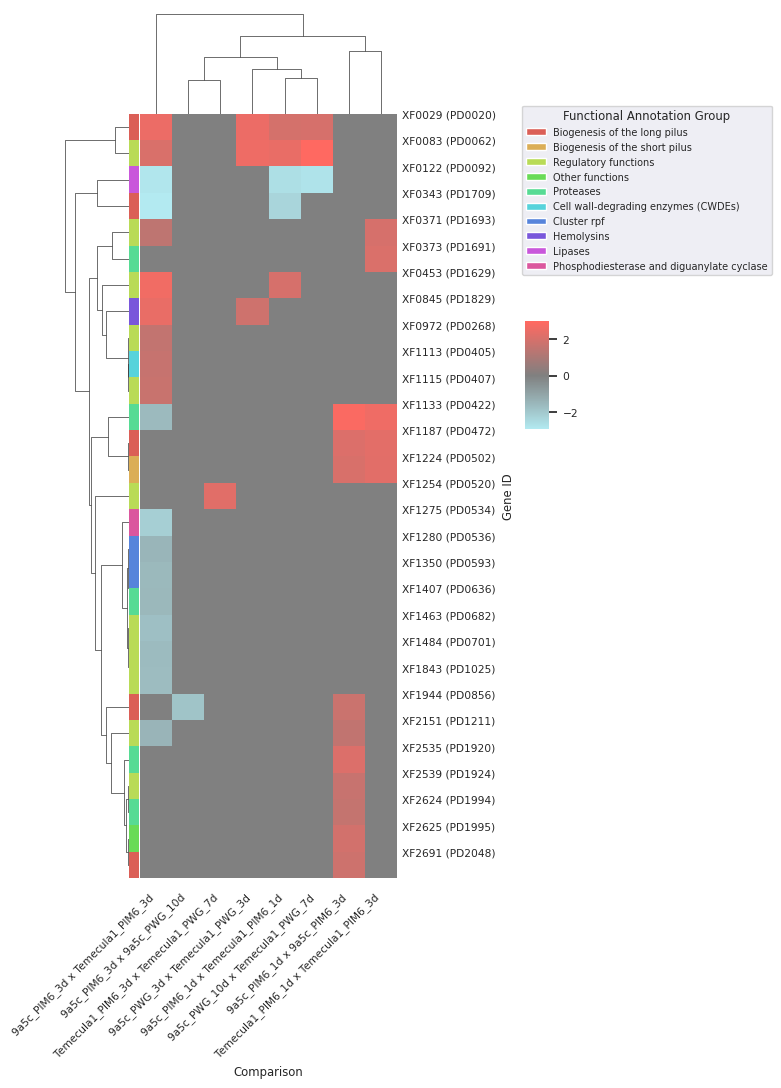

In [42]:
# Load the cleaned data
file_path = "figure_5.csv"
df = pd.read_csv(file_path)

# Strip leading/trailing whitespaces
df.columns = df.columns.str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Pivot table: genes as rows, comparisons as columns
pivot_df = df.pivot_table(index=["Gene ID", "functional annotation group"],
                          columns="Comparison",
                          values="Fold change")

# Fill missing values with 0 (not DEG)
pivot_df = pivot_df.fillna(0)

# Extract row metadata
gene_ids = pivot_df.index.get_level_values("Gene ID")
groups = pivot_df.index.get_level_values("functional annotation group")

# Colors for functional groups
unique_groups = groups.unique()
palette = sns.color_palette("hls", len(unique_groups))
group_colors = dict(zip(unique_groups, palette))
row_colors = groups.map(group_colors)

# Custom diverging colormap: dark blue (down), light gray (zero), dark red (up)
cmap = LinearSegmentedColormap.from_list("custom", ["#B3EBF2", "#808080", "#FF6961"])

# Prepare clustermap
sns.set(font_scale=0.7)
# g = sns.clustermap(pivot_df.droplevel("functional annotation group"),
#                    cmap=cmap,
#                    row_colors=row_colors,
#                    figsize=(4, 12),
#                    linewidths=0.001,  # thinner lines between cells
#                    dendrogram_ratio=(.2, .12),
#                    cbar_pos=(0.04, 0.85, 0.15, 0.15),
#                    xticklabels=True,
#                    yticklabels=True,
#                    center=0)
g = sns.clustermap(pivot_df.droplevel("functional annotation group"),
                   cmap=cmap,
                   row_colors=row_colors,
                   figsize=(4, 12),
                   linewidths=0.0,  # thinner lines between cells
                   dendrogram_ratio=(.2, .12),
                   xticklabels=True,
                   yticklabels=True,
                   center=0)


# Format y-axis to show gene IDs but remove tick marks
g.ax_heatmap.set_yticks(range(len(gene_ids)))
g.ax_heatmap.set_yticklabels(gene_ids)
g.ax_heatmap.tick_params(axis='y', length=0)  # remove tick marks

# Tilt x- and y-axis labels
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), ha='left')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

# Add functional annotation legend
handles = [Patch(facecolor=group_colors[name], label=name) for name in group_colors]
g.ax_row_dendrogram.legend(handles=handles,
                           title='Functional Annotation Group',
                           loc='center left',
                           bbox_to_anchor=(6.8, 0.90),
                           fontsize='small')

# Title and layout
plt.subplots_adjust(right=0.87, top=0.95)
# plt.suptitle("Transcriptome Clustermap by Functional Annotation Group", fontsize=14)

cb = g.cax  # this is the mappable/colorbar Axes
cb.set_position([1.19, 0.6, 0.06, 0.09]) 

# Show or save
plt.savefig("transcriptome_clustermap.tiff", dpi=600, bbox_inches='tight')
plt.show()


In [3]:
cd /mnt/c/Users/oseia/OneDrive/Documents/02_academic/publications/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22

/mnt/c/Users/oseia/OneDrive/pierry_paper/Paper transcritoma 9a5c e Tem1-maio22/Paper transcritoma 9a5c e Tem1-maio22


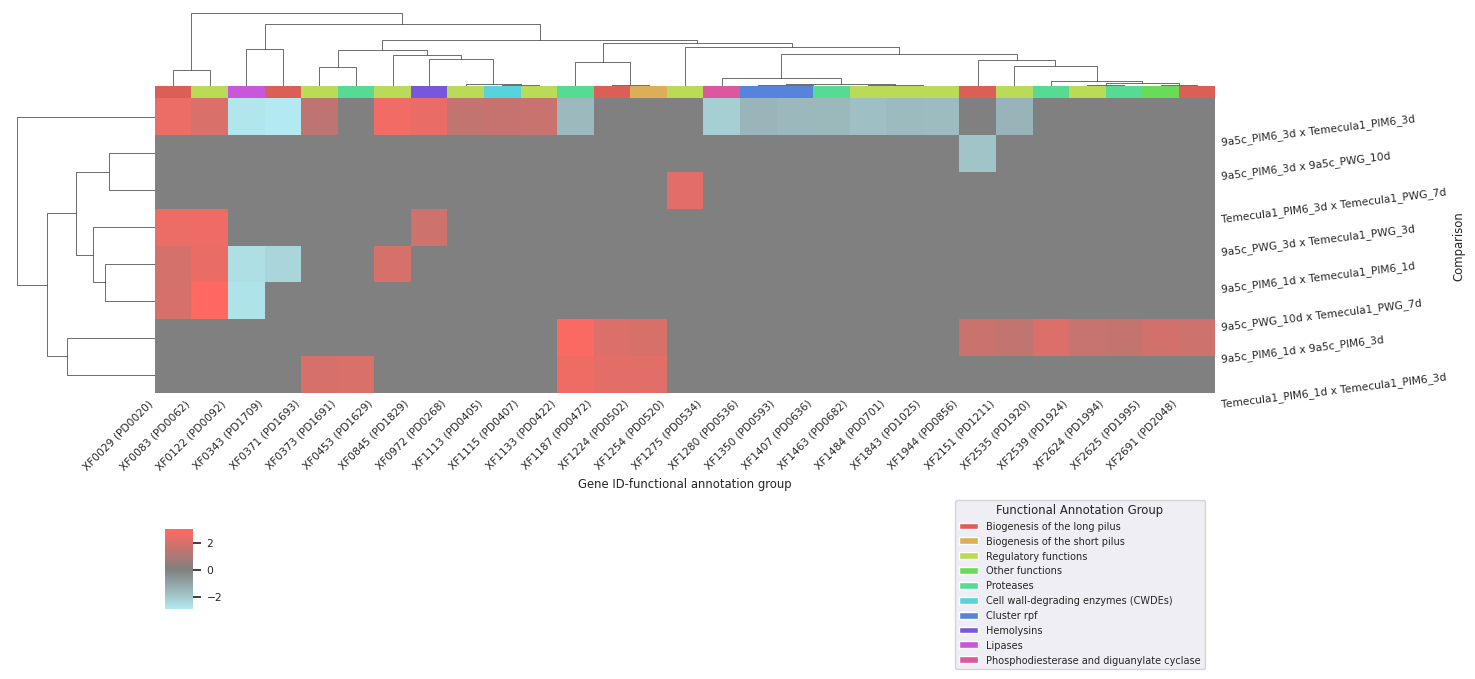

In [79]:
# Load the cleaned data
file_path = "figure_5.csv"
df = pd.read_csv(file_path)

# Strip leading/trailing whitespaces
df.columns = df.columns.str.strip()
df = df.map(lambda x: x.strip() if isinstance(x, str) else x)

# Pivot table: comparisons as rows, genes as columns
pivot_df = df.pivot_table(index="Comparison",
                          columns=["Gene ID", "functional annotation group"],
                          values="Fold change")

# Fill missing values with 0 (not DEG)
pivot_df = pivot_df.fillna(0)

# Extract column metadata
gene_ids = pivot_df.columns.get_level_values("Gene ID")
groups = pivot_df.columns.get_level_values("functional annotation group")

# Colors for functional groups
unique_groups = groups.unique()
palette = sns.color_palette("hls", len(unique_groups))
group_colors = dict(zip(unique_groups, palette))
col_colors = groups.map(group_colors)

# Custom diverging colormap: dark blue (down), light gray (zero), dark red (up)
cmap = LinearSegmentedColormap.from_list("custom", ["#B3EBF2", "#808080", "#FF6961"])

# Prepare clustermap
sns.set(font_scale=0.7)
g = sns.clustermap(pivot_df,
                   cmap=cmap,
                   col_colors=col_colors,
                   figsize=(14, 8),  # wider figure now that genes are horizontal
                   linewidths=0.0,
                   dendrogram_ratio=(.12, .2),
                   xticklabels=True,
                   yticklabels=True,
                   center=0)



# Format x-axis to show gene IDs but remove tick marks
g.ax_heatmap.set_xticks(range(len(gene_ids)))
g.ax_heatmap.set_xticklabels(gene_ids, rotation=90, ha='center')
g.ax_heatmap.tick_params(axis='x', length=0)
g.ax_heatmap.tick_params(axis='y', length=0)  # remove tick marks

# Tilt y-axis labels for readability
g.ax_heatmap.set_yticklabels(g.ax_heatmap.get_yticklabels(), rotation=7, ha='left')
g.ax_heatmap.set_xticklabels(g.ax_heatmap.get_xticklabels(), rotation=45, ha='right')

# Add functional annotation legend
handles = [Patch(facecolor=group_colors[name], label=name) for name in group_colors]
g.ax_col_dendrogram.legend(handles=handles,
                           title='Functional Annotation Group',
                           loc='center left',
                           bbox_to_anchor=(0.75, -6.5),
                           fontsize='small')

# Title and layout
plt.subplots_adjust(right=0.87, top=0.95)
# grab the colorbar Axes and give it a new position

cb = g.cax  # this is the mappable/colorbar Axes
cb.set_position([0.12, 0.2, 0.02, 0.1]) 

#  [x0, y0, width, height] in figure‐fraction coords
# plt.suptitle("Transcriptome Clustermap by Functional Annotation Group", fontsize=14)
# Show or save
plt.savefig("transcriptome_clustermap_transposed.tiff", dpi=600, bbox_inches='tight')
plt.show()